# 03_osteo_dataloader_basico

Objetivo:
- cargar el `active_subset` de Osteoarthritis,
- construir el `Dataset` y los `DataLoader`,
- unificar imágenes con modos distintos (`RGB`, `I;16`),
- aplicar mejora local de contraste con CLAHE,
- redimensionar a 224x224,
- convertir la entrada a 3 canales para usar un backbone preentrenado,
- validar que batches, labels y shapes estén correctos.

## Imports y rutas

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

DATASET_NAME = "osteo"

META_DIR = WORKING_DIR / DATASET_NAME / "meta"
SUBSETS_DIR = WORKING_DIR / DATASET_NAME / "subsets"

ACTIVE_SUBSET_PATH = META_DIR / f"{DATASET_NAME}_active_subset.csv"
MASTER_MANIFEST_PATH = MANIFESTS_DIR / f"{DATASET_NAME}_master_manifest.csv"
LABEL_MAP_PATH = META_DIR / f"{DATASET_NAME}_label_map.json"

print("ACTIVE_SUBSET_PATH:", ACTIVE_SUBSET_PATH)
print("MASTER_MANIFEST_PATH:", MASTER_MANIFEST_PATH)
print("LABEL_MAP_PATH:", LABEL_MAP_PATH)

ACTIVE_SUBSET_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_active_subset.csv
MASTER_MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/osteo_master_manifest.csv
LABEL_MAP_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_label_map.json


## Cargar subset activo y label map

In [2]:
df = pd.read_csv(ACTIVE_SUBSET_PATH)
master_df = pd.read_csv(MASTER_MANIFEST_PATH)

with open(LABEL_MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

label_to_idx = label_map["label_to_idx"]
idx_to_label = {int(k): v for k, v in label_map["idx_to_label"].items()}

print("Shape active subset:", df.shape)
print("Shape master manifest:", master_df.shape)
print("label_to_idx:", label_to_idx)
print("idx_to_label:", idx_to_label)

display(df.head())

Shape active subset: (4766, 8)
Shape master manifest: (4766, 7)
label_to_idx: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
idx_to_label: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}


,image_id,filename,file_path,label_text,target_label,split,source_dataset,subset_name
0,SevereG4 (233),SevereG4 (233).png,/mnt/d/Universidad/analitica/proyecto_analitic...,4,4,train,osteo,large
1,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
2,MildG2 (232),MildG2 (232).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
3,NormalG0 (64),NormalG0 (64).png,/mnt/d/Universidad/analitica/proyecto_analitic...,0,0,val,osteo,large
4,MildG2 (144),MildG2 (144).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large


## Confirmar subset activo y splits

In [3]:
if "subset_name" in df.columns:
    print("subset_name:", df["subset_name"].value_counts(dropna=False).to_dict())
else:
    print(" No existe columna subset_name. Se asumirá que el CSV activo es el correcto.")

print("\nConteo por split:")
display(df["split"].value_counts().rename_axis("split").reset_index(name="count"))

print("\nConteo por clase:")
display(
    df["label_text"]
    .astype(str)
    .value_counts()
    .sort_index()
    .rename_axis("label_text")
    .reset_index(name="count")
)

subset_name: {'large': 4766}

Conteo por split:


,split,count
0,train,3336
1,val,715
2,test,715



Conteo por clase:


,label_text,count
0,0,1315
1,1,1266
2,2,765
3,3,742
4,4,678


## Parámetros del loader

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True

USE_CLAHE = True
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

USE_TRAIN_AUG = False  # déjalo en False para este notebook básico
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Importar OpenCV para CLAHE

In [6]:
try:
    import cv2
    print("cv2 versión:", cv2.__version__)
except ImportError as e:
    raise ImportError(
        "No se encontró OpenCV. Instálalo con: pip install opencv-python"
    ) from e

cv2 versión: 4.13.0


## Helpers de lectura y preprocesado

In [7]:
def to_gray_uint8(path_str: str) -> np.ndarray:
    path = Path(path_str)

    with Image.open(path) as img:
        arr = np.array(img)

    # Caso RGB/RGBA
    if arr.ndim == 3:
        if arr.shape[2] == 4:
            arr = arr[:, :, :3]

        if arr.dtype != np.uint8:
            arr = arr.astype(np.float32)
            mn, mx = arr.min(), arr.max()
            if mx > mn:
                arr = ((arr - mn) / (mx - mn) * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = np.zeros(arr.shape[:2] + (arr.shape[2],), dtype=np.uint8)

        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    # Caso grayscale
    elif arr.ndim == 2:
        if arr.dtype != np.uint8:
            arr = arr.astype(np.float32)
            mn, mx = arr.min(), arr.max()
            if mx > mn:
                arr = ((arr - mn) / (mx - mn) * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = np.zeros_like(arr, dtype=np.uint8)

    else:
        raise ValueError(f"Formato de imagen no soportado: shape={arr.shape}")

    return arr


def apply_clahe(gray_uint8: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size=(8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    return clahe.apply(gray_uint8)


def preprocess_osteo_image(path_str: str,
                           image_size=(224, 224),
                           use_clahe: bool = True,
                           clahe_clip_limit: float = 2.0,
                           clahe_tile_grid_size=(8, 8)) -> Image.Image:
    gray = to_gray_uint8(path_str)

    if use_clahe:
        gray = apply_clahe(
            gray,
            clip_limit=clahe_clip_limit,
            tile_grid_size=clahe_tile_grid_size
        )

    pil_gray = Image.fromarray(gray)
    pil_gray = pil_gray.resize(image_size, Image.BILINEAR)

    # convertimos a 3 canales para backbone preentrenado
    pil_rgb = Image.merge("RGB", (pil_gray, pil_gray, pil_gray))
    return pil_rgb

## Comparación visual antes y después de CLAHE

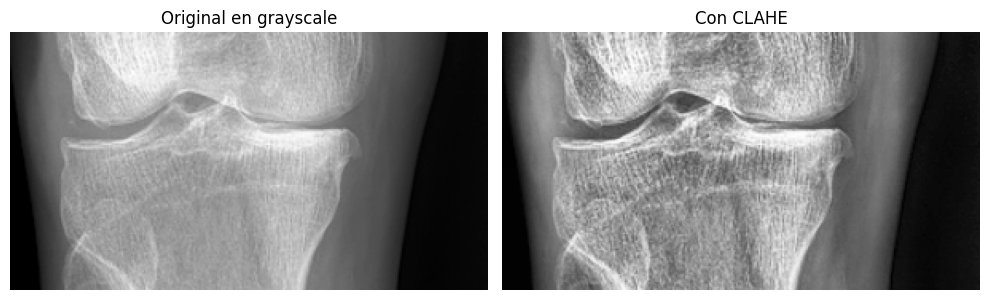

In [8]:
sample_path = df["file_path"].iloc[0]

gray_raw = to_gray_uint8(sample_path)
gray_clahe = apply_clahe(
    gray_raw,
    clip_limit=CLAHE_CLIP_LIMIT,
    tile_grid_size=CLAHE_TILE_GRID_SIZE
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_raw, cmap="gray")
plt.title("Original en grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_clahe, cmap="gray")
plt.title("Con CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

## Transforms finales

In [9]:
if USE_TRAIN_AUG:
    train_post_transform = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=7),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
else:
    train_post_transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

eval_post_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_post_transform)
print(eval_post_transform)

Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Dataset

In [10]:
class OsteoDataset(Dataset):
    def __init__(self, dataframe, post_transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.post_transform = post_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = preprocess_osteo_image(
            path_str=row["file_path"],
            image_size=IMAGE_SIZE,
            use_clahe=USE_CLAHE,
            clahe_clip_limit=CLAHE_CLIP_LIMIT,
            clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE
        )

        if self.post_transform is not None:
            image = self.post_transform(image)

        label = int(row["target_label"])

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "image_id": row["image_id"],
            "file_path": row["file_path"],
            "label_text": str(row["label_text"]),
            "split": row["split"],
        }

## Separar train / val / test

In [11]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (3336, 8)
val_df: (715, 8)
test_df: (715, 8)


## Crear datasets

In [12]:
train_dataset = OsteoDataset(train_df, post_transform=train_post_transform)
val_dataset = OsteoDataset(val_df, post_transform=eval_post_transform)
test_dataset = OsteoDataset(test_df, post_transform=eval_post_transform)

print("len(train_dataset):", len(train_dataset))
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))

len(train_dataset): 3336
len(val_dataset): 715
len(test_dataset): 715


## Probar una muestra

In [13]:
sample = train_dataset[0]

print("Keys:", sample.keys())
print("image shape:", sample["image"].shape)
print("image dtype:", sample["image"].dtype)
print("label:", sample["label"])
print("label_text:", sample["label_text"])
print("split:", sample["split"])
print("image_id:", sample["image_id"])

Keys: dict_keys(['image', 'label', 'image_id', 'file_path', 'label_text', 'split'])
image shape: torch.Size([3, 224, 224])
image dtype: torch.float32
label: tensor(4)
label_text: 4
split: train
image_id: SevereG4 (233)


## Visualizar una muestra desnormalizada

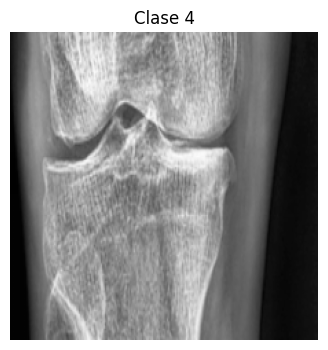

In [14]:
def denormalize_tensor(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor.cpu() * std) + mean

img = sample["image"]
img_vis = denormalize_tensor(img).clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(np.transpose(img_vis.numpy(), (1, 2, 0)))
plt.title(f"Clase {sample['label_text']}")
plt.axis("off")
plt.show()

## Crear DataLoaders

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 105
val batches: 23
test batches: 23


## Validar un batch

In [16]:
batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("images.shape:", images.shape)
print("images.dtype:", images.dtype)
print("labels.shape:", labels.shape)
print("labels.dtype:", labels.dtype)
print("labels[:10]:", labels[:10].tolist())
print("min/max tensor:", float(images.min()), float(images.max()))

images.shape: torch.Size([32, 3, 224, 224])
images.dtype: torch.float32
labels.shape: torch.Size([32])
labels.dtype: torch.int64
labels[:10]: [4, 1, 2, 0, 3, 0, 0, 0, 0, 4]
min/max tensor: -2.1007792949676514 2.640000104904175


## Visualizar batch pequeño

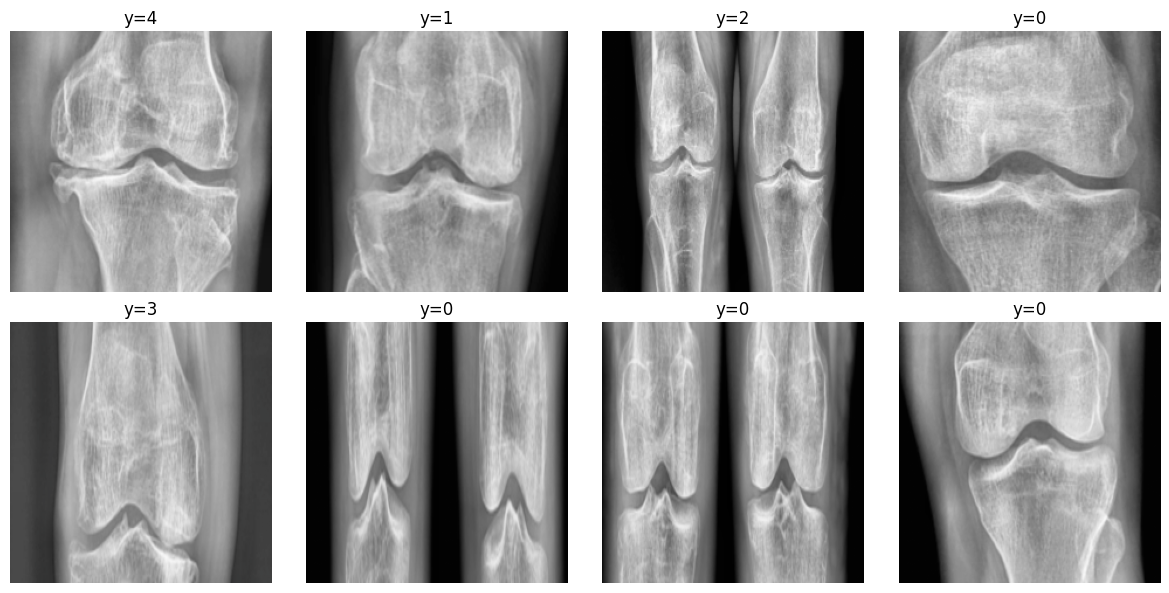

In [17]:
n_show = min(8, images.shape[0])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(len(axes)):
    ax = axes[i]
    if i < n_show:
        img_vis = denormalize_tensor(images[i]).clamp(0, 1)
        ax.imshow(np.transpose(img_vis.numpy(), (1, 2, 0)))
        ax.set_title(f"y={labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Distribución del train y class weights

In [18]:
train_class_counts = (
    train_df["target_label"]
    .value_counts()
    .sort_index()
)

display(train_class_counts.rename_axis("target_label").reset_index(name="count"))

n_train = len(train_df)
n_classes = train_df["target_label"].nunique()

class_weights = n_train / (n_classes * train_class_counts.values.astype(np.float32))
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("class_weights:", class_weights)

,target_label,count
0,0,921
1,1,886
2,2,535
3,3,520
4,4,474


class_weights: tensor([0.7244, 0.7530, 1.2471, 1.2831, 1.4076])


## Guardar class weights para el notebook 04

In [19]:
class_weights_path = META_DIR / f"{DATASET_NAME}_class_weights.pt"
torch.save(class_weights, class_weights_path)

print("Guardado class_weights en:", class_weights_path)

Guardado class_weights en: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_class_weights.pt


## Batch a GPU para validación rápida

In [20]:
images_gpu = images.to(DEVICE, non_blocking=True)
labels_gpu = labels.to(DEVICE, non_blocking=True)

print("images_gpu.device:", images_gpu.device)
print("labels_gpu.device:", labels_gpu.device)
print("images_gpu.shape:", images_gpu.shape)
print("labels_gpu.shape:", labels_gpu.shape)

images_gpu.device: cuda:0
labels_gpu.device: cuda:0
images_gpu.shape: torch.Size([32, 3, 224, 224])
labels_gpu.shape: torch.Size([32])


## Resumen del notebook

In [21]:
summary = {
    "dataset_name": DATASET_NAME,
    "active_rows": int(len(df)),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "use_clahe": USE_CLAHE,
    "clahe_clip_limit": CLAHE_CLIP_LIMIT,
    "clahe_tile_grid_size": CLAHE_TILE_GRID_SIZE,
    "use_train_aug": USE_TRAIN_AUG,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "device": DEVICE,
    "class_weights": class_weights.tolist(),
}

summary

{'dataset_name': 'osteo',
 'active_rows': 4766,
 'train_rows': 3336,
 'val_rows': 715,
 'test_rows': 715,
 'image_size': (224, 224),
 'batch_size': 32,
 'use_clahe': True,
 'clahe_clip_limit': 2.0,
 'clahe_tile_grid_size': (8, 8),
 'use_train_aug': False,
 'num_workers': 4,
 'pin_memory': True,
 'device': 'cuda',
 'class_weights': [0.7244299650192261,
  0.7530474066734314,
  1.2471028566360474,
  1.2830768823623657,
  1.407594919204712]}